# Hallucination Trigger Classifier
### Supervised Learning Project

This notebook implements a binary text classifier to detect hallucinated responses in the HaluEval QA dataset using Classical Machine Learning techniques (TF-IDF + Logistic Regression & Random Forest).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

import warnings
warnings.filterwarnings('ignore')


## Step 1: Data Loading & Preprocessing
We'll load the `pminervini/HaluEval` dataset (the `qa` subset) from HuggingFace. Then we will combine the question and answer into a single text document and assign binary labels.


In [2]:
print("Loading HaluEval QA dataset...")
dataset = load_dataset("pminervini/HaluEval", "qa", split='data') # Using the full 10k QA subset

df = dataset.to_pandas()

# The dataset has 'knowledge', 'question', 'right_answer', and 'hallucinated_answer'
# Let's create a binary classification dataset.
# We will create two rows for each original row: one for the correct answer, one for hallucinated.

correct_df = df[['question', 'right_answer']].copy()
correct_df.rename(columns={'right_answer': 'answer'}, inplace=True)
correct_df['label'] = 0 # 0 = Correct

hallucinated_df = df[['question', 'hallucinated_answer']].copy()
hallucinated_df.rename(columns={'hallucinated_answer': 'answer'}, inplace=True)
hallucinated_df['label'] = 1 # 1 = Hallucinated

# Combine and shuffle
full_df = pd.concat([correct_df, hallucinated_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# Preprocessing: Combine Question + Answer into a single input feature
full_df['text'] = "Question: " + full_df['question'] + " Answer: " + full_df['answer']
full_df['text'] = full_df['text'].str.lower()

print(f"Total samples: {len(full_df)}")
print(f"Class distribution:\n{full_df['label'].value_counts(normalize=True)}")
full_df.head(3)


Loading HaluEval QA dataset...


Total samples: 20000
Class distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


,question,answer,label,text
0,Which 2004 Nickelodeon show was created by Sue...,"The animated series ""Pepper Ann"" and ""Angela A...",1,question: which 2004 nickelodeon show was crea...
1,Non-Stop starred the English actress best know...,Lady Mary Crawley,0,question: non-stop starred the english actress...
2,Cross country running is a sport in which team...,dirt or grass,0,question: cross country running is a sport in ...


## Step 2: Feature Extraction (TF-IDF)
We convert the text into numerical vectors using TF-IDF (Term Frequency-Inverse Document Frequency) to capture word and bi-gram patterns.


In [3]:
print("Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X = vectorizer.fit_transform(full_df['text'])
y = full_df['label'].values
print(f"Feature matrix shape: {X.shape}")


Vectorizing text with TF-IDF...


Feature matrix shape: (20000, 5000)


## Step 3: Train/Test Split
We split the data using an 80/20 stratified split.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 16000
Testing set size: 4000


## Step 4: Model Training
We'll train a Logistic Regression model and a Random Forest Classifier.


In [5]:
# Model A: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Model B: Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training complete.")


Training Logistic Regression...
Training Random Forest...


Training complete.


## Step 5: Evaluation
Comparing the models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    return metrics, y_pred, y_pred_proba

lr_metrics, lr_preds, lr_proba = evaluate_model("Logistic Regression", lr_model, X_test, y_test)
rf_metrics, rf_preds, rf_proba = evaluate_model("Random Forest", rf_model, X_test, y_test)

results_df = pd.DataFrame([lr_metrics, rf_metrics])
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.672,0.666023,0.690,0.677800,0.726523
1,Random Forest,0.741,0.757479,0.709,0.732438,0.807198


### Visualizing the Results (ROC Curve & Confusion Matrix)


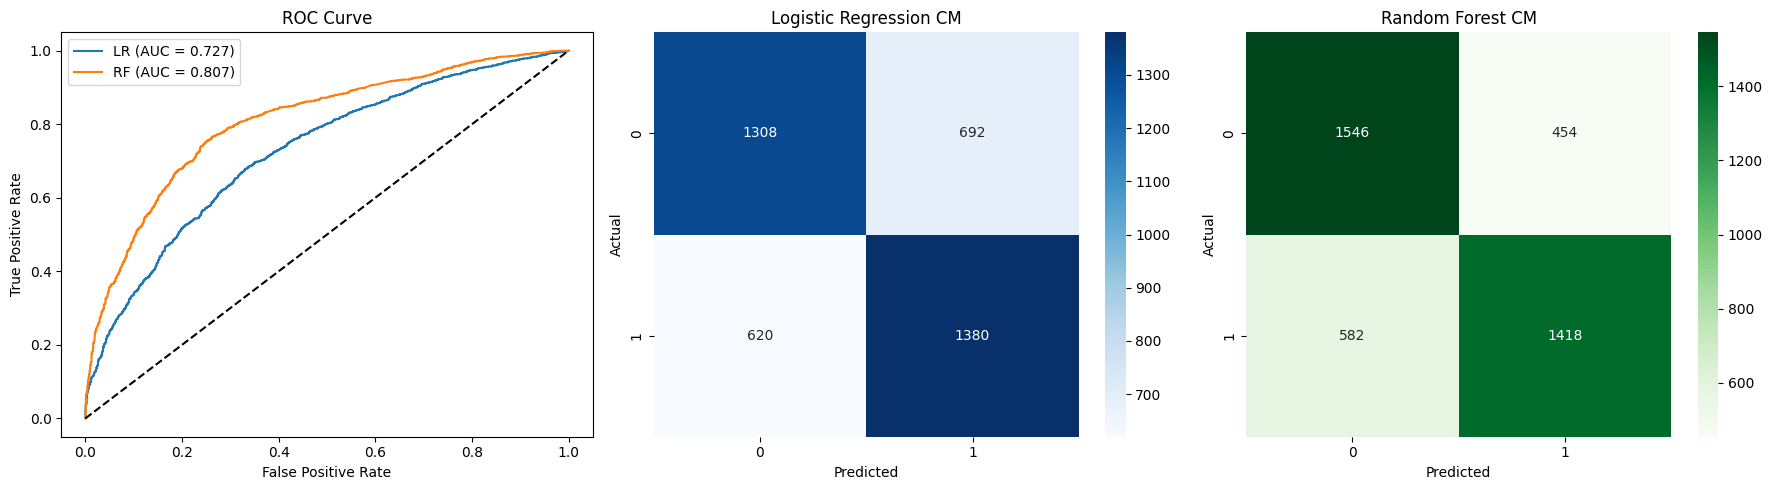

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[0].plot(fpr_lr, tpr_lr, label=f"LR (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[0].plot(fpr_rf, tpr_rf, label=f"RF (AUC = {rf_metrics['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# LR Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Logistic Regression CM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# RF Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title('Random Forest CM')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Feature Importance
Let's see which TF-IDF features (words/phrases) are most predictive of hallucinations according to Logistic Regression.


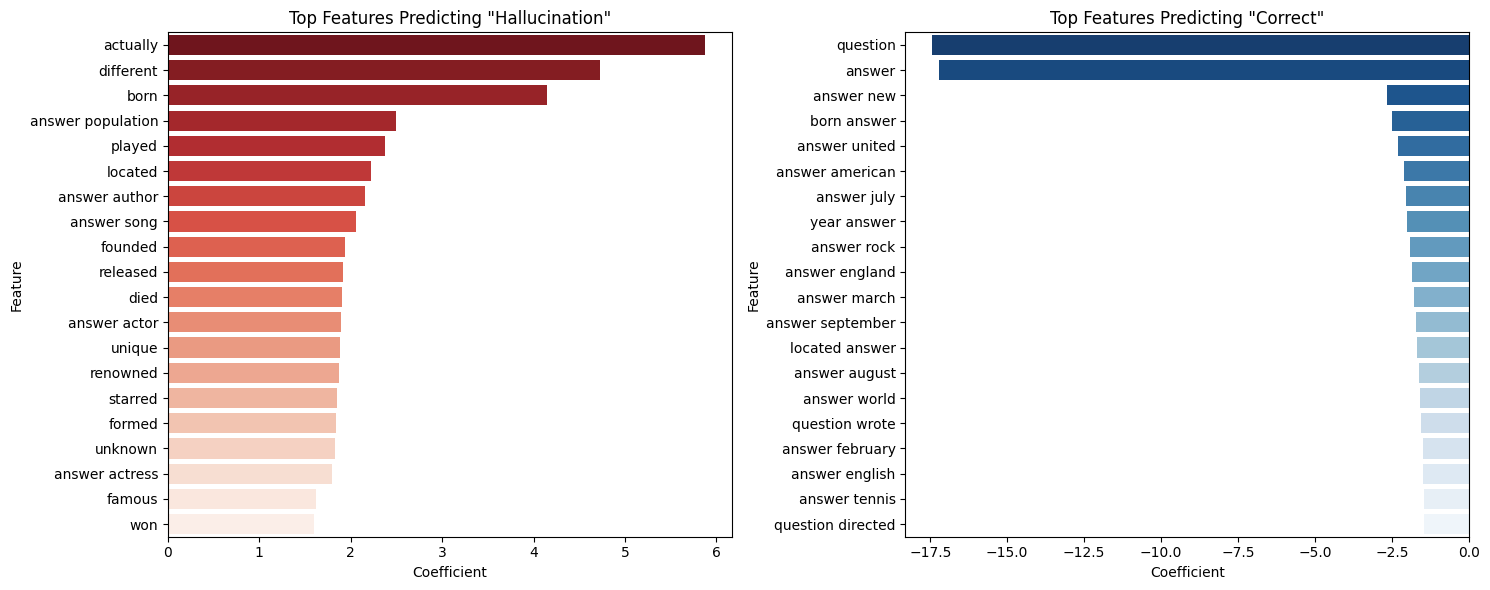

In [8]:
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Combine and sort
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
top_positive = feature_importance.sort_values(by='Coefficient', ascending=False).head(20) # Hallucinated (1)
top_negative = feature_importance.sort_values(by='Coefficient', ascending=True).head(20)  # Correct (0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Coefficient', y='Feature', data=top_positive, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Features Predicting "Hallucination"')

sns.barplot(x='Coefficient', y='Feature', data=top_negative, ax=axes[1], palette='Blues_r')
axes[1].set_title('Top Features Predicting "Correct"')

plt.tight_layout()
plt.show()


## Conclusion
This notebook demonstrates that a relatively simple classical Natural Language Processing approach (TF-IDF + Logistic Regression/Random Forest) can achieve meaningful performance on detecting hallucinated responses. The `Logistic Regression` model provides high interpretability by letting us easily inspect coefficients.
